# Notebook 7: Plot map of plume top heights


## Imports

In [1]:
import warnings

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore")

In [2]:
out_dir = "./plots/"

## Get and prepare data

In [3]:
t = np.datetime64("2025-05-30T03:00:00")
names = ["E0", "E10", "E30", "E50", "E70", "E70*"]

In [4]:
def compute_smoke_top(var, t, threshold=1e-8):
    var_t = var.sel(time=t)

    mask = var_t >= threshold
    height_3d = var_t["height"] * mask

    smoke_top = height_3d.max("height")

    return smoke_top

In [5]:
h = xr.open_dataset(
    "./data/grids/lam_hra_2025_atm_vgrid_ml.nc",
    engine="netcdf4",
).mean("ncells").zg

h = h.rename({"height_2": "height"})

In [6]:
grid = xr.open_mfdataset("./data/grids/hra_DOM01.nc", engine = 'netcdf4')
lon = np.rad2deg(grid.clon)
lat = np.rad2deg(grid.clat)

path_fires = "./data/modis/modis_regridded.nc" 

fires  = xr.open_mfdataset(path_fires, engine='netcdf4')

In [7]:
threshold = 1000

var = fires.frp.sel(time=np.datetime64("2025-05-30 00:00:00"), method = "nearest") 
mask = (var >= threshold).compute()
fires_f = mask * var

fire_lons = lon.where(mask, drop = True)
fire_lats = lat.where(mask, drop = True)


## Read Data

In [8]:
path = "/work/bb1174/user/jason/hra_data/hra_post_proc/"
filetype = "/*.nc"
variable = "ca_volc"

files = path + "pp_hra_25" + filetype
d1 = xr.open_mfdataset(files, engine='netcdf4', combine='by_coords').assign_coords(height=h)[variable]
print("Dataset loaded")

files = path + "pp_hra_27" + filetype
d2 = xr.open_mfdataset(files, engine='netcdf4', combine='by_coords').assign_coords(height=h)[variable]
print("Dataset loaded")

files = path + "pp_hra_31" + filetype
d3 = xr.open_mfdataset(files, engine='netcdf4', combine='by_coords').assign_coords(height=h)[variable]
print("Dataset loaded")

files = path + "pp_hra_23" + filetype
d4 = xr.open_mfdataset(files, engine='netcdf4', combine='by_coords').assign_coords(height=h)[variable]
print("Dataset loaded")

files = path + "pp_hra_28" + filetype
d5 = xr.open_mfdataset(files, engine='netcdf4', combine='by_coords').assign_coords(height=h)[variable]
print("Dataset loaded")

files = path + "pp_hra_29" + filetype
d6 = xr.open_mfdataset(files, engine='netcdf4', combine='by_coords').assign_coords(height=h)[variable]
print("Dataset loaded")


Dataset loaded
Dataset loaded
Dataset loaded
Dataset loaded
Dataset loaded
Dataset loaded


In [9]:
test = xr.open_mfdataset(files, engine='netcdf4', combine='by_coords').assign_coords(height=h)

## Map of trc top heights

In [10]:
datasets = [
    d1,
    d2,
    d3,
    d4,
    d5,
    d6,
]

fields = [compute_smoke_top(ds, t) for ds in datasets]
for da in fields:
    da[0] = 15000     #This is an ugly workaround to keep the allow much easier colormap handling 

In [11]:
lon_min, lon_max = np.min(lon), np.max(lon)
lat_min, lat_max = np.min(lat), np.max(lat)

In [12]:
# -------------------------------------------------
# Plot settings
# -------------------------------------------------
fs = 14

# Map extent
pad = 1

#Unit
unit_conversion = 1e-3

# Smoke-top range [km]
vmin = 2
vmax = 14
threshold = 10

# Colormap
n = 256
grey_fraction = (threshold - vmin) / (vmax - vmin)

n_grey = int(n * grey_fraction)
n_plasma = n - n_grey

grey_cmap = get_cmap("Greys")
plasma_cmap = get_cmap("plasma")

grey_colors = grey_cmap(
    np.linspace(0.15, 0.75, n_grey)
)

plasma_colors = plasma_cmap(
    np.linspace(0, 1, n_plasma)
)

combined_colors = np.vstack([
    grey_colors,
    plasma_colors,
])

cmap = mcolors.LinearSegmentedColormap.from_list(
    "grey_plasma",
    combined_colors,
    N=n,
)

norm = mcolors.Normalize(
    vmin=vmin,
    vmax=vmax,
)

levels = np.linspace(vmin, vmax, 41)

# Figure
figsize = (20, 7)

panel_labels = ["a", "b", "c", "d", "e", "f"]

# Colorbar position
colorbar_position = [0.54, 0.15, 0.02, 0.7]

# Figure layout
fig_left = 0.05
fig_right = 0.5
fig_bottom = 0.05
fig_top = 0.95
fig_wspace = 0.1
fig_hspace = 0.001

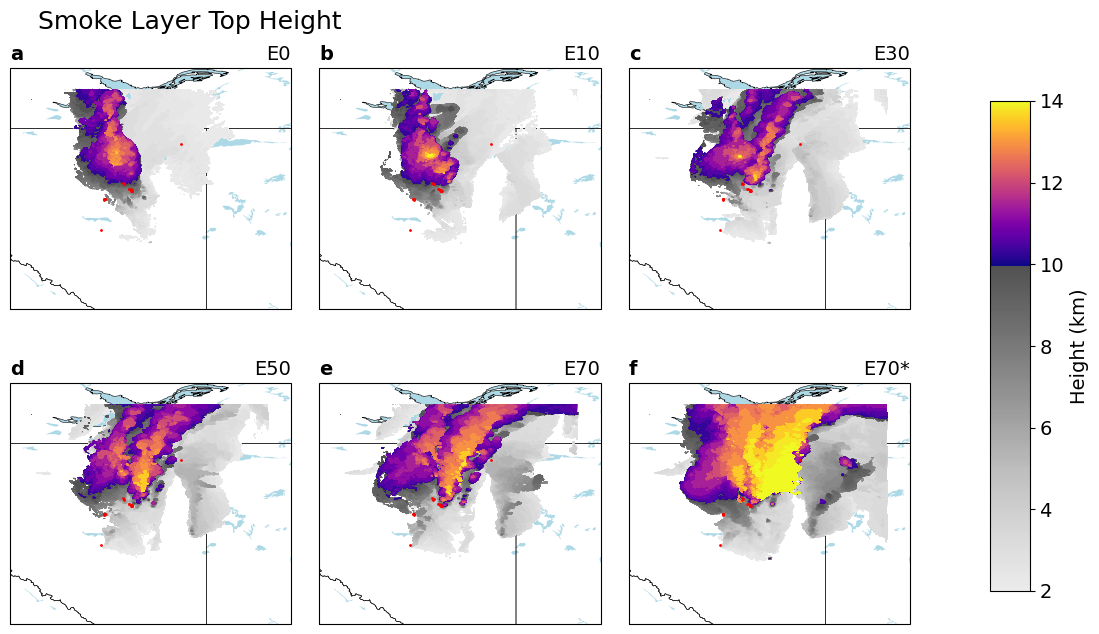

In [13]:
# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, axes = plt.subplots(
    2,
    3,
    figsize=figsize,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

axes = axes.flatten()

for ax, field, title, panel_label in zip(
    axes,
    fields,
    names,
    panel_labels,
):

    # -------------------------------------------------
    # Map features
    # -------------------------------------------------
    ax.add_feature(
        cfeature.LAKES,
        facecolor="lightblue",
        edgecolor="none",
        zorder=0,
    )

    ax.add_feature(
        cfeature.STATES,
        linewidth=0.4,
        zorder=1,
    )

    ax.set_extent(
        [
            lon_min - pad,
            lon_max + pad,
            lat_min - pad,
            lat_max + pad,
        ],
        crs=ccrs.PlateCarree(),
    )

    # -------------------------------------------------
    # Smoke-top field
    # -------------------------------------------------
    ax.tricontourf(
        lon,
        lat,
        field * unit_conversion,
        levels=levels,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        zorder=2,
        extend="max",
    )

    # -------------------------------------------------
    # Fire locations
    # -------------------------------------------------
    ax.scatter(
        fire_lons,
        fire_lats,
        c="red",
        s=1,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

    # -------------------------------------------------
    # Titles
    # -------------------------------------------------
    ax.set_title(
        panel_label,
        loc="left",
        fontsize=fs,
        fontweight = "bold"
    )

    ax.set_title(
        title,
        loc="right",
        fontsize=fs,
    )

# -------------------------------------------------
# Colorbar
# -------------------------------------------------
cax = fig.add_axes(colorbar_position)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    ),
    cax=cax,
)

cbar.set_label(
    "Height (km)",
    fontsize=fs,
)

cbar.ax.tick_params(
    labelsize=fs,
)

# -------------------------------------------------
# Figure title
# -------------------------------------------------
fig.suptitle(
    "Smoke Layer Top Height",
    fontsize=fs + 4,
    y=0.98,
    x=0.14,
)

# -------------------------------------------------
# Layout
# -------------------------------------------------
fig.subplots_adjust(
    left=fig_left,
    right=fig_right,
    bottom=fig_bottom,
    top=fig_top,
    wspace=fig_wspace,
    hspace=fig_hspace,
)

plt.show()
fig.savefig(out_dir + "plume_top_map.png", dpi=300, bbox_inches="tight")